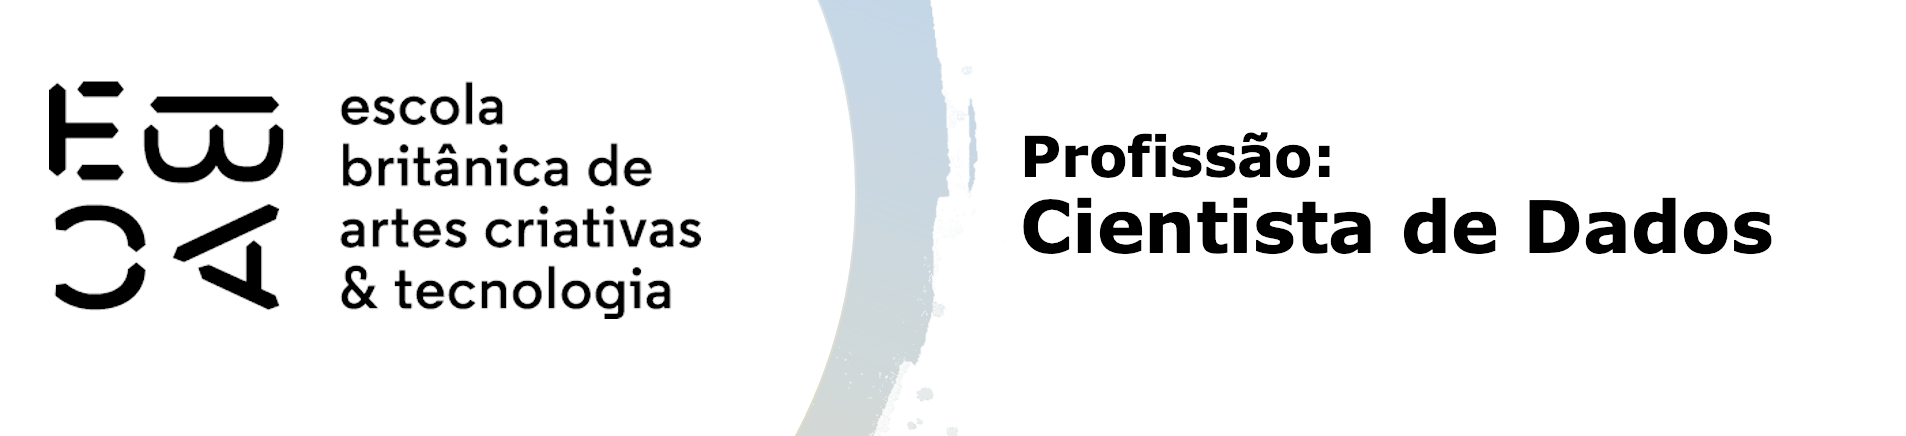

# Métodos hierárquicos de agrupamento - Tarefa

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

import scipy.cluster.hierarchy as shc

## 1) Repetindo o que fizemos em aula

Primeiramente vamos repetir o que fizemos em aula com a base de pinguins.

1. Selecione as variáveis quantitativas da base de pinguins
2. Elimine valores faltantes
3. Padronize as variáveis para média zero e desvio padrão 1
4. Faça um agrupamento hierárquico dividindo essa base em 3 grupos
5. Faça o Dendrograma

In [27]:
# Cria o objeto de agrupamento hierárquico aglomerativo com 3 grupos, usando o método de ligação completa
clus = AgglomerativeClustering(
    n_clusters=3,
    linkage="complete",
    distance_threshold=None,
)

# Cria o objeto para padronizar os dados (média 0 e desvio padrão 1)
padronizador = StandardScaler()

In [28]:
# Carrega o dataset dos pinguins do seaborn
penguins = sns.load_dataset("penguins")

# Seleciona apenas as colunas numéricas (float64 e int64) do dataframe
penguins_only_numeric = penguins.select_dtypes(include=['float64', 'int64'])

In [29]:
# Exibe as linhas do DataFrame 'penguins_only_numeric' que possuem pelo menos um valor ausente (NaN)
penguins_only_numeric[penguins_only_numeric.isna().any(axis=1)] 

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
3,NaN,NaN,NaN,NaN
339,NaN,NaN,NaN,NaN


In [30]:
# Exibe as linhas do DataFrame 'penguins_only_numeric' que possuem pelo menos um valor ausente (NaN)
penguins_only_numeric[penguins_only_numeric.isna().any(axis=1)]

# Remove do DataFrame 'penguins' as linhas que possuem valores ausentes nas colunas numéricas
penguins = penguins.dropna(subset=penguins_only_numeric.columns)

# Remove do DataFrame 'penguins_only_numeric' as linhas que possuem valores ausentes
penguins_only_numeric.dropna(inplace=True)

In [31]:
penguins_only_numeric_std = pd.DataFrame(padronizador.fit_transform(penguins_only_numeric), columns=penguins_only_numeric.columns)

In [32]:
clus.fit(penguins_only_numeric_std)

AgglomerativeClustering(linkage='complete', n_clusters=3)

In [33]:
penguins['Grupos_3'] = clus.labels_

Text(0.5, 1.0, 'Dendrograma - Método Completo')

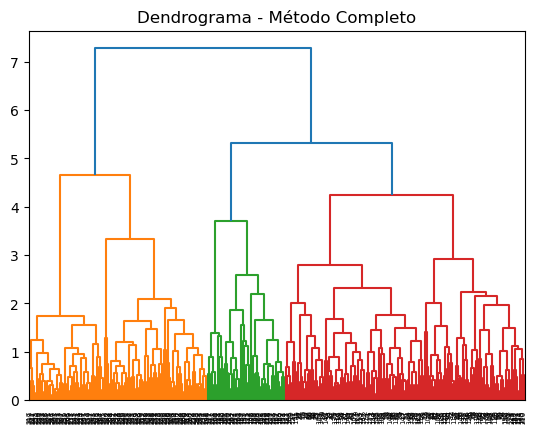

In [34]:
dend = shc.dendrogram(shc.linkage(penguins_only_numeric_std, method='complete'))
plt.title('Dendrograma - Método Completo')

## 2) Avalie os grupos

Descreva os grupos:

- Quantos pinguins de cada espécie há em cada grupo?
- Descreva as variáveis quantitativas de cada grupo com as técnicas que você preferir.

In [35]:
penguins_only_numeric.columns

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')

In [36]:
pd.crosstab(penguins['species'], penguins[ 'Grupos_3'])

Grupos_3,0,1,2
species,,,
Adelie,0,151,0
Chinstrap,0,14,54
Gentoo,123,0,0


Text(0.5, 1.0, 'Agrupamento Hierárquico Aglomerativo - Pinguins')

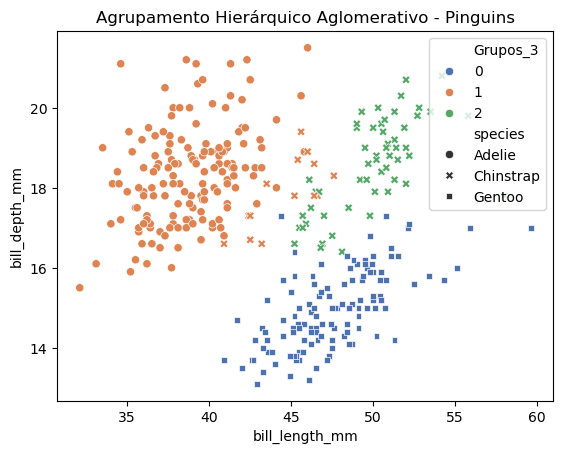

In [37]:
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='Grupos_3', style='species', palette='deep')
plt.title('Agrupamento Hierárquico Aglomerativo - Pinguins')

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

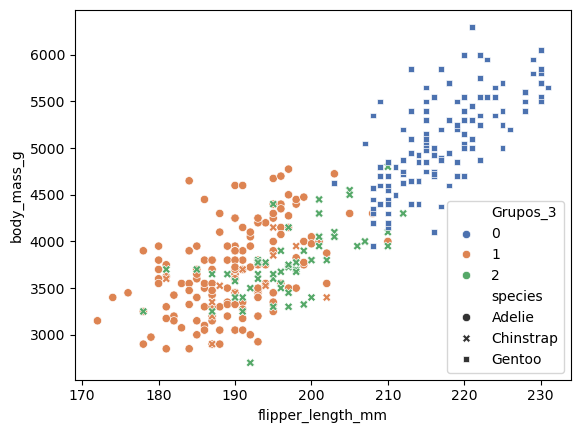

In [38]:
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', hue='Grupos_3', style='species', palette='deep')

## 3) Alterando o agrupamento

O Dendrogarma sugere que podemem haver grupos interessantes se solicitarmos mais que 3 grupos. Se quisermos testar o agrupamento com mais de 3 grupos, quantos grupos o Dendrograma te sugere? (Dica: não faça mais que 6 grupos).

- Faça o agrupamento hierárquico semelhante ao anterior, mas com o número de grupos que você escolheu.
- Analise esses agrupamentos
    - Quantos pinguins de cada espécie há em cada grupo?
    - Quantos pinguins de cada espécie machos e fêmeas há em cada grupo?
- Na sua opinião, o agrupamento capturou algum padrão natural dos dados? Qual?

In [39]:
# Cria o objeto de agrupamento hierárquico aglomerativo com 3 grupos, usando o método de ligação completa
clus = AgglomerativeClustering(
    n_clusters=5,
    linkage="complete",
    distance_threshold=None,
)

# Cria o objeto para padronizar os dados (média 0 e desvio padrão 1)
padronizador = StandardScaler()

In [40]:
clus.fit(penguins_only_numeric_std)

AgglomerativeClustering(linkage='complete', n_clusters=5)

In [41]:
penguins['Grupos_5'] = clus.labels_

In [54]:
pd.crosstab(
    penguins["species"],
    penguins["Grupos_3"],
    rownames=["Espécies"],
    colnames=["3 Grupos"],
    margins=True,
)

3 Grupos,0,1,2,All
Espécies,,,,
Adelie,0,151,0,151
Chinstrap,0,14,54,68
Gentoo,123,0,0,123
All,123,165,54,342


In [55]:
pd.crosstab(
    penguins["species"],
    penguins["Grupos_5"],
    rownames=["Espécies"],
    colnames=["5 Grupos"],
    margins=True,
)

5 Grupos,0,1,2,3,4,All
Espécies,,,,,,
Adelie,0,0,60,0,91,151
Chinstrap,54,0,9,0,5,68
Gentoo,0,71,0,52,0,123
All,54,71,69,52,96,342


Text(0.5, 1.0, 'Agrupamento Hierárquico Aglomerativo - Pinguins')

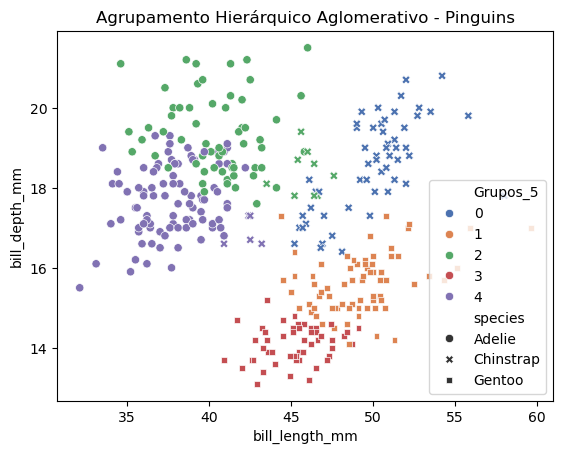

In [43]:
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='Grupos_5', style='species', palette='deep')
plt.title('Agrupamento Hierárquico Aglomerativo - Pinguins')

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

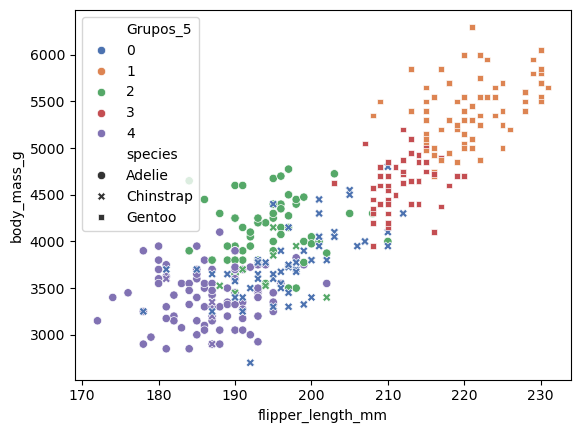

In [44]:
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', hue='Grupos_5', style='species', palette='deep')

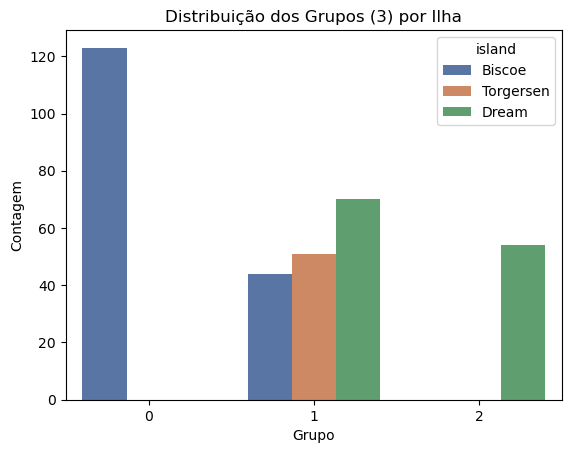

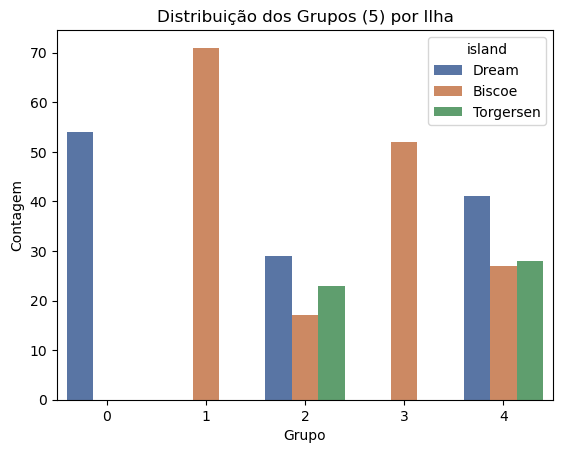

In [63]:
# Gráfico de contagem dos grupos (3 e 5) por ilha dos pinguins

# Gráfico para os 3 grupos
sns.countplot(data=penguins, x='Grupos_3', hue='island', palette='deep')
plt.title('Distribuição dos Grupos (3) por Ilha')
plt.xlabel('Grupo')
plt.ylabel('Contagem')
plt.show()

# Gráfico para os 5 grupos
sns.countplot(data=penguins, x='Grupos_5', hue='island', palette='deep')
plt.title('Distribuição dos Grupos (5) por Ilha')
plt.xlabel('Grupo')
plt.ylabel('Contagem')
plt.show()

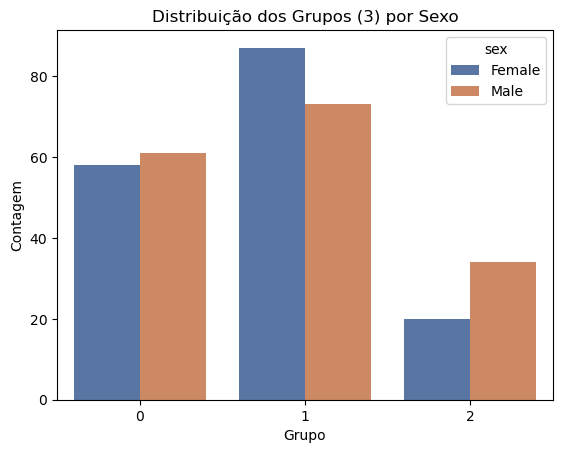

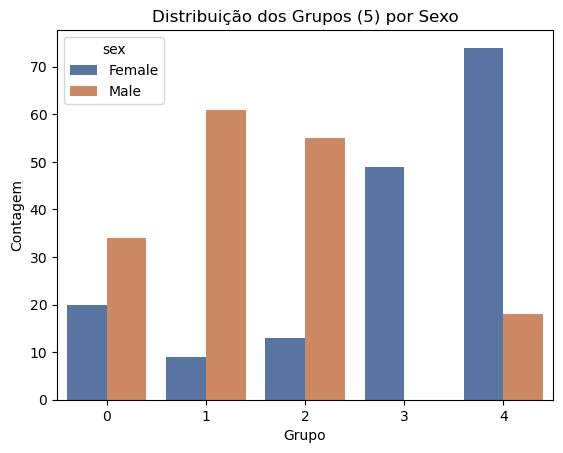

In [62]:
# Gráfico de contagem dos grupos (3 e 5) por sexo dos pinguins

# Gráfico para os 3 grupos
sns.countplot(data=penguins, x='Grupos_3', hue='sex', palette='deep')
plt.title('Distribuição dos Grupos (3) por Sexo')
plt.xlabel('Grupo')
plt.ylabel('Contagem')
plt.show()

# Gráfico para os 5 grupos
sns.countplot(data=penguins, x='Grupos_5', hue='sex', palette='deep')
plt.title('Distribuição dos Grupos (5) por Sexo')
plt.xlabel('Grupo')
plt.ylabel('Contagem')
plt.show()

In [53]:
pd.crosstab(
    penguins["sex"],
    penguins["Grupos_3"],
    rownames=["Sexo"],
    colnames=["3 Grupos"],
)

3 Grupos,0,1,2
Sexo,,,
Female,58,87,20
Male,61,73,34


In [52]:
pd.crosstab(
    penguins["sex"],
    penguins["Grupos_5"],
    rownames=["Sexo"],
    colnames=["5 Grupos"],
)

5 Grupos,0,1,2,3,4
Sexo,,,,,
Female,20,9,13,49,74
Male,34,61,55,0,18


Resposta: Ambos agrupamentos desempenharam papéis muito semelhantes, sendo fiéis inclusive na quantidade de erros, embora estes erros estejam mais distribuidos no modelo de 5 grupos, mas a proporção permanece a mesma. Não é possível determinar qual forma de agrupamento explicou melhor os dados